In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="NRGT1qSbcEQxTmMGkyin")
project = rf.workspace("traffic-5wyfb").project("face-mask-6394b")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...


# Face Mask Detection - PyTorch CNN

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

## Load File Paths

In [3]:
import os
# Find where your data actually is
drives = ['C:', 'D:', 'E:', 'F:']
search = 'with_mask'
for drive in drives:
    for root, dirs, files in os.walk(drive + '\\'):
        if search in dirs:
            print(os.path.join(root, search))
        break  # only check top level, remove this to do full search

In [4]:
base_path = r'D:\Mask-detection\face-mask-1'
print(os.listdir(base_path))

['README.dataset.txt', 'README.roboflow.txt', 'without_mask', 'with_mask']


In [5]:
with_mask_files = os.listdir(r'D:\Mask-detection\face-mask-1\with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['1002_png.rf.db246ff612a6c1306c889575b86831aa.jpg', '1004_png.rf.644c1381cd635c54ff5d4246458d9acf.jpg', '1005_png.rf.9db3e522adaffae5b3aca469c19c0de7.jpg', '1006_png.rf.3100c949c1eddd86e0159726c600a87c.jpg', '1008_png.rf.8768662f3f0ad1586fca5114c2eb6756.jpg']
['with_mask_995.jpg', 'with_mask_996.jpg', 'with_mask_997.jpg', 'with_mask_998.jpg', 'with_mask_999.jpg']


In [6]:
without_mask_files = os.listdir(r'D:\Mask-detection\face-mask-1\without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['1000_png.rf.5baf59c9f35fb53801d8ce07e7c4953d.jpg', '1001_png.rf.90939207d71c009d03e46ec394e14698.jpg', '1002_png.rf.b64fb5727b4def4ba71c92f466975c44.jpg', '1004_png.rf.e5f7911cd4b4093c8b0a9481cf35cbc4.jpg', '1005_png.rf.71014d2aec97225557bf130464931989.jpg']
['without_mask_995.jpg', 'without_mask_996.jpg', 'without_mask_997.jpg', 'without_mask_998.jpg', 'without_mask_999.jpg']


In [7]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 8184
Number of without mask images: 8400


## Create Labels

In [8]:
with_mask_labels = [1] * len(with_mask_files)
without_mask_labels = [0] * len(without_mask_files)

print(with_mask_labels[0:5])
print(without_mask_labels[0:5])
print(len(with_mask_labels), len(without_mask_labels))

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]
8184 8400


In [9]:
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

16584
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


## Display Sample Images

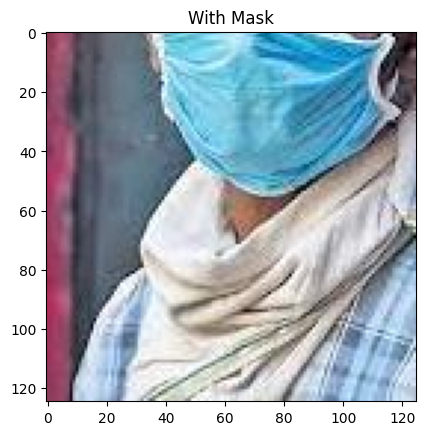

In [10]:
img = mpimg.imread(r'D:\Mask-detection\face-mask-1\with_mask\2_png.rf.c973eed25258ea44ea4513fba5f8de18.jpg')
plt.imshow(img)
plt.title('With Mask')
plt.show()

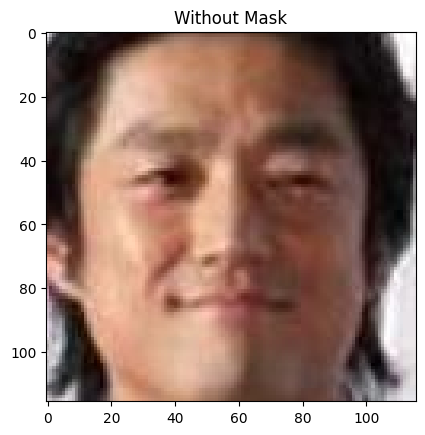

In [11]:
img = mpimg.imread(r'D:\Mask-detection\face-mask-1\without_mask\208_png.rf.3bbdbe47dd90e8ce69df90f59c31b6ac.jpg')
plt.imshow(img)
plt.title('Without Mask')
plt.show()

## Image Processing — Resize & Convert to Arrays

In [12]:
with_mask_path = r'D:\Mask-detection\face-mask-1\with_mask/'
without_mask_path = r'D:\Mask-detection\face-mask-1\without_mask/'

data = []

for img_file in with_mask_files:
    image = Image.open(with_mask_path + img_file)
    image = image.resize((128, 128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

for img_file in without_mask_files:
    image = Image.open(without_mask_path + img_file)
    image = image.resize((128, 128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

print('Total images loaded:', len(data))
print('Image shape:', data[0].shape)

Palette images with Transparency expressed in bytes should be converted to RGBA images


Total images loaded: 16584
Image shape: (128, 128, 3)


## Convert to NumPy Arrays & Scale

In [13]:
X = np.array(data)      # Shape: (N, 128, 128, 3)  — HWC format
Y = np.array(labels)

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (16584, 128, 128, 3)
Y shape: (16584,)


## Train / Test Split

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)
print('X:', X.shape, '  X_train:', X_train.shape, '  X_test:', X_test.shape)

X: (16584, 128, 128, 3)   X_train: (13267, 128, 128, 3)   X_test: (3317, 128, 128, 3)


## Scale & Convert to PyTorch Tensors

PyTorch expects images in **CHW** format (channels first), unlike TensorFlow's HWC.

In [15]:
# Scale to [0, 1]
X_train_scaled = X_train / 255.0
X_test_scaled  = X_test  / 255.0

# Convert HWC -> CHW  (N, H, W, C) -> (N, C, H, W)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).permute(0, 3, 1, 2)
Y_train_t = torch.tensor(Y_train, dtype=torch.long)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.long)

print('Train tensors:', X_train_t.shape, Y_train_t.shape)
print('Test tensors: ', X_test_t.shape,  Y_test_t.shape)

Train tensors: torch.Size([13267, 3, 128, 128]) torch.Size([13267])
Test tensors:  torch.Size([3317, 3, 128, 128]) torch.Size([3317])


## Create DataLoaders

In [16]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, Y_train_t)
test_dataset  = TensorDataset(X_test_t,  Y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader))
print('Test batches: ', len(test_loader))

Train batches: 415
Test batches:  104


## Build CNN Model

Mirrors the Keras architecture: Conv → Pool → Conv → Pool → Flatten → Dense → Dropout → Dense → Dropout → Output

In [17]:
class MaskCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(MaskCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)  # -> (32, 126, 126)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)                     # -> (32, 63, 63)

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3) # -> (64, 61, 61)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)                     # -> (64, 30, 30)

        # Fully connected layers
        # Flattened size: 64 * 30 * 30 = 57600
        self.fc1     = nn.Linear(64 * 30 * 30, 128)
        self.drop1   = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(128, 64)
        self.drop2   = nn.Dropout(p=0.5)
        self.out     = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)   # flatten
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        x = self.out(x)              # raw logits; CrossEntropyLoss handles softmax
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = MaskCNN(num_classes=2).to(device)
print(model)

Using device: cpu
MaskCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=57600, out_features=128, bias=True)
  (drop1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (drop2): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=64, out_features=2, bias=True)
)


## Compile — Loss & Optimizer

`CrossEntropyLoss` (equivalent to Keras `sparse_categorical_crossentropy`) + Adam optimizer.

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training Loop

In [19]:
EPOCHS = 10
VAL_SPLIT = 0.1

# Split train_loader data further for a validation set (mirrors Keras validation_split=0.1)
train_size = int((1 - VAL_SPLIT) * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_sub, val_sub = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_sub_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
val_loader       = DataLoader(val_sub,   batch_size=BATCH_SIZE, shuffle=False)

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels_batch in train_sub_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_batch).sum().item()
        total   += labels_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            val_loss    += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels_batch).sum().item()
            val_total   += labels_batch.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc  = val_correct / val_total

    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(val_epoch_loss)
    history['val_accuracy'].append(val_epoch_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}]  '
          f'Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}  '
          f'Val Loss: {val_epoch_loss:.4f}  Val Acc: {val_epoch_acc:.4f}')

Epoch [1/10]  Loss: 0.3088  Acc: 0.8714  Val Loss: 0.2095  Val Acc: 0.9133
Epoch [2/10]  Loss: 0.2129  Acc: 0.9178  Val Loss: 0.1915  Val Acc: 0.9314
Epoch [3/10]  Loss: 0.1900  Acc: 0.9225  Val Loss: 0.1607  Val Acc: 0.9390
Epoch [4/10]  Loss: 0.1638  Acc: 0.9364  Val Loss: 0.1517  Val Acc: 0.9435
Epoch [5/10]  Loss: 0.1499  Acc: 0.9426  Val Loss: 0.1589  Val Acc: 0.9442
Epoch [6/10]  Loss: 0.1291  Acc: 0.9498  Val Loss: 0.1500  Val Acc: 0.9472
Epoch [7/10]  Loss: 0.1186  Acc: 0.9553  Val Loss: 0.1433  Val Acc: 0.9503
Epoch [8/10]  Loss: 0.1005  Acc: 0.9611  Val Loss: 0.1283  Val Acc: 0.9578
Epoch [9/10]  Loss: 0.0869  Acc: 0.9659  Val Loss: 0.1307  Val Acc: 0.9548
Epoch [10/10]  Loss: 0.0817  Acc: 0.9690  Val Loss: 0.1691  Val Acc: 0.9367


## Model Evaluation on Test Set

In [20]:
model.eval()
test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for images, labels_batch in test_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        test_loss    += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        test_correct += (predicted == labels_batch).sum().item()
        test_total   += labels_batch.size(0)

print(f'Test Loss:     {test_loss / test_total:.4f}')
print(f'Test Accuracy: {test_correct / test_total:.4f}')

Test Loss:     0.1573
Test Accuracy: 0.9406


## Plot Loss & Accuracy Curves

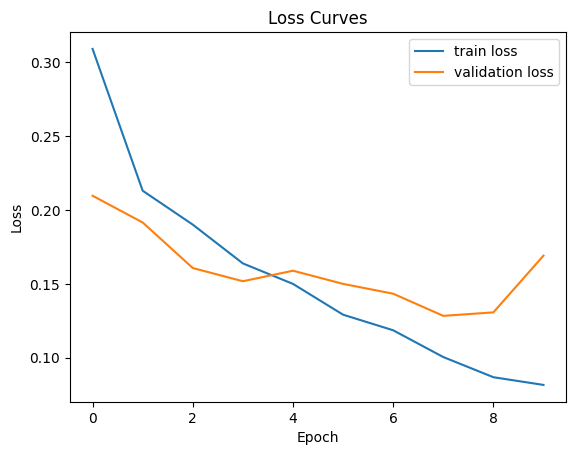

In [21]:
plt.plot(history['loss'],     label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

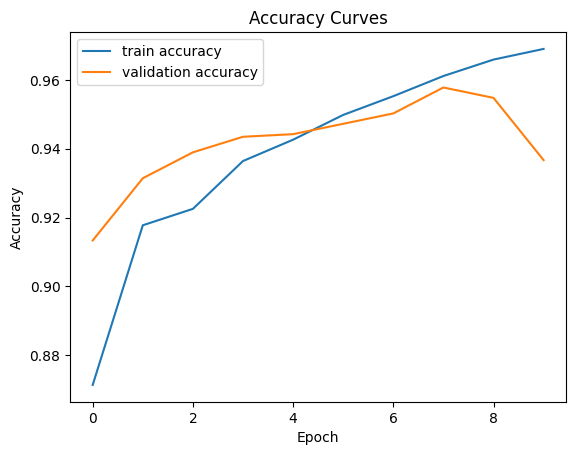

In [22]:
plt.plot(history['accuracy'],     label='train accuracy')
plt.plot(history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')
plt.show()

## Save the Model

PyTorch convention: save the `state_dict` (weights only), not the full model object.

In [23]:
# Save weights only (recommended)
torch.save(model.state_dict(), 'mask_model.pth')
print('Model saved to mask_model.pth')

Model saved to mask_model.pth


In [24]:
# To reload later:
# model = MaskCNN(num_classes=2)
# model.load_state_dict(torch.load('mask_model.pth'))
# model.eval()